# ML Week 19: AutoEncoders

So far in this course we have talked about the vector (or in the general case, tensor) which results from multiple convolutions. This has many names:

* Embedding (vector)
* Latent space (vector)
* Feature space (vector)

but regardless of what you call it, the idea is simple. The vector should represent the "essence" of the data put into the network.

However, the networks we have seen so far have been trained with a goal in mind (ie. Classification, Detection, Segmentation).

Our choice of "downstream task" will affect the nature of the learned embeddings.

So one may ask: what would be the "purest" form of an embedding?

These questions are at the heart of an insanely powerful AI architecture known as the AutoEncoder (AE).

The idea is simple: squish some input down to a very small vector/tensor (this is called the "bottleneck"), then try to reconstruct it. The loss is the difference between the input and the reconstruction. This is great way to get a very good embedding vector, which can then be used for many other tasks.

<div>
<img src="./AE.png" width="700"/>
</div>
Source: Wikipedia

The theory has existed since the 80s, with early examples appearing in the 00s.

A 2011 paper introduced a Convolutional AutoEncoder (CAE):
https://people.idsia.ch/~ciresan/data/icann2011.pdf

<div>
<img src="./CAE.png" width="700"/>
</div>
Note: this image is not from the paper (which had no architecture diagram). It came from here: https://github.com/arthurmeyer/Saliency_Detection_Convolutional_Autoencoder

The AlexNet breakthrough in 2012 saw a flurry of new AutoEncoder architectures in the 2010s, most notably the Variational AutoEncoder in 2013 and U-Net in 2015. In the 2020s Transformers have been integrated into AutoEncoder architectures, notably the Masked AutoEncoder (MAE).

Today, AutoEncoders are a HUGE family of different architectures that all serve different purposes and have their respective advantages and disadvantages.

Most AutoEncoders can learn without labels, hence they are usually referred to as **self-supervised** models.

### Deconvolutions

Most AutoEncoders consist of 3 parts:

* The Encoder which "squishes" down the input. We have seen many examples of this in CNNs. The Encoder is often a very familiar network (often a ResNet).

* The Bottleneck, which is where we arrive at the embedding vector (or tensor). There can also be a few fully connected (FC) layers.

* The Decoder which tries to learn how to reconstruct the image.

The first two parts we have seen before, but how the heck does the Decoder reconstruct the image??

This is done with "deconvolutions", also sometimes called "upsampling".

<div>
<img src="./Upsample.png" width="500"/>
</div>

Let's give it a try!

In [12]:
import torch
from torch import nn

input = torch.arange(1, 5, dtype=torch.float32).view(1,1,2,2)

input

tensor([[[[1., 2.],
          [3., 4.]]]])

In [31]:
m = nn.Upsample(scale_factor=2, mode='nearest')
m(input)

tensor([[[[1., 1., 2., 2.],
          [1., 1., 2., 2.],
          [3., 3., 4., 4.],
          [3., 3., 4., 4.]]]])

In [233]:
# Another varient which uses interpolation

m = nn.Upsample(scale_factor=2, mode='bilinear')
m(input)

tensor([[[[1.0000, 1.2500, 1.7500, 2.0000],
          [1.5000, 1.7500, 2.2500, 2.5000],
          [2.5000, 2.7500, 3.2500, 3.5000],
          [3.0000, 3.2500, 3.7500, 4.0000]]]])

Subsequent convolutions after upsampling can learn to "shape" this data, eventually reconstructing images (although the reconstruction will in general never be as good as what we started with).

To see a rough example of how this would work, see Exercise 3.

## Convolutional AutoEncoder

Let's build and train a full Convoluational AutoEncoder!

How do we do it?

* For the Encoder we will use a ResNet18
* We add an extra layer to squish the ResNet18 output to a length 64\*2\*2 = 256 tensor (the embedding)
* Then we Deconvolve back up to the imput size and see how we did

What about the dataset?

We will use a dataset of Turkish Byzantine Roman Mosaics, found here:
https://www.kaggle.com/datasets/gisemos/classification-data-of-mosaics-and-frescos

**Note**:
For a full research project:
* The images should be taken at similar angles, distances from the mosaics, with similar lighting. AutoEncoders can be quite sensitive to this
* The AE should be trained over many more epochs
* The pixel variance and standard deviation in the dataset should be measured for proper image normalization
* The size of the bottleneck should be tested to see if 256 is truly optimal (bigger may work better)

Ultimately this is just a toy example to see how it works.

In [ ]:
# The TIMM (Torch Image Multi-Models) library downloads models from Hugging Face.
# For me, there is a connection issue to Hugging Face unless I disable a parametre with the following code
# It may not be necessary for you

import os

os.environ["HF_HUB_DISABLE_XET"] = "1"

### Defining the Convolutional AutoEncoder Model

Note: Previously we could use models easily from Ultralytics. Unfortunately, after trying many libraries (Pythae, Hugging Face, etc.), I have concluded that AE are just too numerous with so many uses that it is tough to find EXACTLY what you want out-of-box. I think using a model from the TIMM library for the encoder, and then manually creating the rest, is the best approach.

In [ ]:
import torch
import torch.nn as nn

import timm

# Here we create the structure of our AutoEncoder
class TimmAutoencoder(nn.Module):
    def __init__(self):  # Ignore this - software stuff
        super().__init__()  # Ignore this - software stuf

        # ENCODER (ResNet18)
        self.backbone = timm.create_model(
            "resnet18",
            pretrained=True,
            features_only=True
        )

        # BOTTLENECK
        self.latent_conv = nn.Conv2d(512, 64, kernel_size=1)

        # DECODER
        self.decoder = nn.Sequential(

            # 64x2x2 -> 256x4x4
            nn.ConvTranspose2d(64, 256, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),

            # 256x4x4 -> 128x8x8
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),

            # 128x8x8 -> 64x16x16
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),

            # 64x16x16 -> 32x32x32
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),

            # 32x32x32 -> 3x64x64
            nn.ConvTranspose2d(32, 3, kernel_size=4, stride=2, padding=1),

            # constrain output to [0,1]
            nn.Sigmoid()
        )

    # Useful definitions
    def encode(self, x):
        x = self.backbone(x)[-1]
        z = self.latent_conv(x)
        return z

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x):
        z = self.encode(x)
        recon = self.decode(z)
        return recon, z

### Create some code to scan through the directory to prepare all image files for training

You don't need to understand this

In [229]:
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import os

class ImageFolderFlat(Dataset):
    def __init__(self, root, transform=None):
        self.paths = [
            os.path.join(root, f) for f in os.listdir(root)
            if f.lower().endswith((".jpg", ".jpeg", ".png"))
        ]
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert("RGB")  # use "L" for grayscale
        if self.transform:
            img = self.transform(img)
        return img, 0  # dummy label so it works with the training loop unchanged

### Set everything up for the training

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

# This defines how the image will be manipulated before training
transform = transforms.Compose([
    transforms.Resize((64, 64)),  # Reshape to 64x64, mainly for computational efficiency (not needed if you have GPU)
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5]),
])

# Read in all the data, transform it as defined above, and organize it for the training loop
dataset = ImageFolderFlat("./mosaics/", transform=transform)
loader = DataLoader(dataset, batch_size=1, shuffle=False)

# Put the model where it should be for training
model = TimmAutoencoder().to(device)

# Define how you will measure performance
criterion = nn.MSELoss()

# How much will you adjust the weights after each batch of data
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4
)

### Time to train!

In [ ]:
epochs = 30

for epoch in range(epochs):
    model.train()
    running_loss = 0

    for imgs, _ in loader:
        imgs = imgs.to(device)
        optimizer.zero_grad()  # Reset the gradients
        recon, latent = model(imgs)  # Put an image in the CAE model and receive both the reconstructed image and latent space representation
        loss = criterion(recon, imgs)  # Compare the reconstruction to the initial image to see how we did
        loss.backward()  # Backpropagation
        optimizer.step()
        running_loss += loss.item()

    avg_loss = running_loss / len(loader)

    print(f"Epoch {epoch+1}: {avg_loss:.6f}")

Epoch 1: 0.089824
Epoch 2: 0.089756
Epoch 3: 0.089655
Epoch 4: 0.089583
Epoch 5: 0.089486
Epoch 6: 0.089427
Epoch 7: 0.089383
Epoch 8: 0.089337
Epoch 9: 0.089353
Epoch 10: 0.089362
Epoch 11: 0.089260
Epoch 12: 0.089225
Epoch 13: 0.089130
Epoch 14: 0.089061
Epoch 15: 0.088974
Epoch 16: 0.088858
Epoch 17: 0.088742
Epoch 18: 0.088613
Epoch 19: 0.088532
Epoch 20: 0.088457
Epoch 21: 0.088401
Epoch 22: 0.088336
Epoch 23: 0.088271
Epoch 24: 0.088218
Epoch 25: 0.088169
Epoch 26: 0.088168
Epoch 27: 0.088152
Epoch 28: 0.088134
Epoch 29: 0.088119
Epoch 30: 0.088066
Epoch 31: 0.087959
Epoch 32: 0.087907
Epoch 33: 0.087831
Epoch 34: 0.087747
Epoch 35: 0.087665
Epoch 36: 0.087591
Epoch 37: 0.087528
Epoch 38: 0.087464
Epoch 39: 0.087453
Epoch 40: 0.087404
Epoch 41: 0.087329
Epoch 42: 0.087281
Epoch 43: 0.087241
Epoch 44: 0.087167
Epoch 45: 0.087131
Epoch 46: 0.087108
Epoch 47: 0.087058
Epoch 48: 0.087032
Epoch 49: 0.086996
Epoch 50: 0.086975
Epoch 51: 0.086908
Epoch 52: 0.086907
Epoch 53: 0.086859
Ep

In [202]:
# Save model

torch.save(model.state_dict(), "autoencoder.pth")

How did we do? We'll see in Exercise 2.

# Exercises

### Exercise 1

Each time the model is called on an image (or a batch of images) it returns both the reconstructed image as well as the latent space representation (embedding).

Set an empty list, set the model to "model.eval()" (as opposed to train, this is for running inference), then loop over the images in loader (similar to what was done when we trained). Instead of taking the reconstructed image take the latent representations, flatten them, and append them to your list.

You now have 1D vectors for each image in your dataset! This opens up a world of possibilities: clustering, random forest, anomaly detection, etc. Basically everything we did last year!

In [ ]:
model.eval()

all_embeddings = []

with torch.no_grad():  # I don't actually know if this is necessary - it just prevents further training the model
    for imgs, _ in loader:
        imgs = imgs.to(device)
        _, latent = model(imgs)

        latent = latent.flatten(1)

        all_embeddings.append(latent.cpu())

In [232]:
# Let's check the shape of one of them:
all_embeddings[0].shape

torch.Size([1, 256])

### Exercise 2

Let's compare one of our images to the corresponding reconstruction. Feel free to use LLMs to help you with this problem. Especially the image-to-tensor formatting for model inference can be cumbersome.

Use the image "./val_mosaic.jpg" which was not in our training data.

Read in the image with PIL "Image.open", apply the necssary transforms to feed it into the model. Remember the format should be (batch, channel, height, width).

Take the reconstruction, transform it BACK to RGB: (height, width, channel) and multiplied by 255.

Plot both the original image and the reconstruction. How did we do?

Note: It's very possible the reconstruction sucks. As a sanity check you can retrain the model on just a few images - then it learns to overfit heavily and should at least show something in the reconstruction. Remember this is just to try out a CAE, not a real research project.

In [ ]:
img_path = './val_mosaic.jpg'

img = Image.open(img_path).convert("RGB")


x = transform(img)

# add batch dimension
# (3,H,W) -> (1,3,H,W)
x = x.unsqueeze(0)

x = x.to(device)
model = model.to(device)

model.eval()

with torch.no_grad():
    recon, latent = model(x)  # Put the image in the model to get the reconstruction and latent space representation

# Check sizes (not required, but just for fun)
print("input shape:", x.shape)
print("reconstruction shape:", recon.shape)
print("latent shape:", latent.shape)

input shape: torch.Size([1, 3, 64, 64])
reconstruction shape: torch.Size([1, 3, 64, 64])
latent shape: torch.Size([1, 64, 2, 2])


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-171.0..199.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [4.1052394e-07..174.9328].


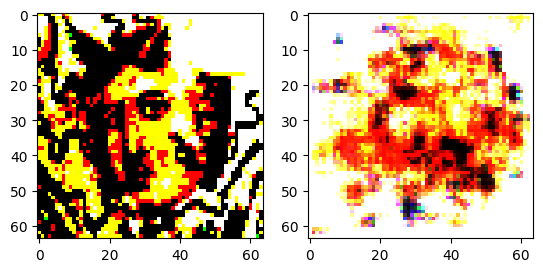

In [ ]:
# Switch the transformed initial image (x) and the reconstruction (recon) back to RGB data for plotting
rgb_tensor = x[0,:3,:,:].permute(1,2,0).cpu()*255
rgb_tensor_recon = recon[0,:3,:,:].permute(1,2,0).cpu()*255

f, ax = plt.subplots(1,2)
im1 = ax[0].imshow(rgb_tensor)
im2 = ax[1].imshow(rgb_tensor_recon)

### Exercise 3.1

Let's again say hi to our friend Mario. Here we will see how kernels can be applied to upscaled images to add details.

Read mario in with the PIL Image.open method, and transform him to a tensor (batch, channel, height, width). Be careful - png images have an alpha channel, so don't be surprised when you have 4 channels. Just take the first 3. Plot him to get started.

torch.Size([1, 4, 16, 16])


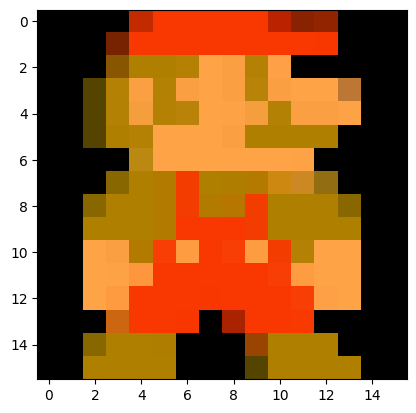

In [225]:
from PIL import Image
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

# Read the image
image = Image.open('mario.png')
img_tensor = transforms.PILToTensor()(image).unsqueeze(0)  # Unsqueeze adds a batch dimension (which is one). This is expected by pytorch tensors
print(img_tensor.shape)  # Note we have shape [1, 4, 16, 16], which is [batch, channel, height, width]. Channel = 4 because png's also have an alpha channel

# View the converted Torch tensor
rgb_tensor = img_tensor[0,:3,:,:].permute(1,2,0)  # This changes it into a siple RGB tensor that matplotlib can handle
plt.imshow(rgb_tensor)

### Exercise 3.2

Now upsample (deconvolve) by a scale of 2 (nearest neighbour method). Make sure that you have only upsampled the height and width.

torch.Size([1, 4, 16, 16])
torch.Size([1, 4, 32, 32])


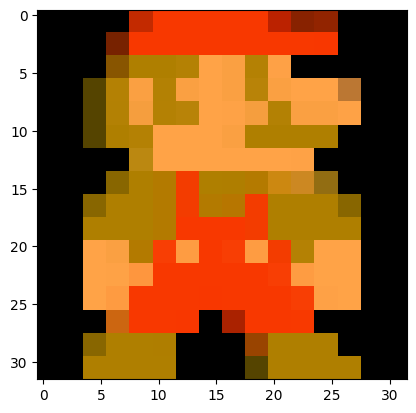

In [226]:
m = nn.Upsample(scale_factor=2, mode='nearest')
upscaled_mario = m(img_tensor)

# Note the height and width have doubled in size
print(img_tensor.shape)
print(upscaled_mario.shape)

# View the converted Torch tensor
rgb_tensor = upscaled_mario[0,:3,:,:].permute(1,2,0)  # This changes it into a siple RGB tensor that matplotlib can handle
plt.imshow(rgb_tensor)

### Exercise 3.3

Our new image is larger, but it doesn't look much different. Below is a kernel that can be used to sharpen edges.

Apply it with torch.conv2d (FYI: you may need to change the mario tensor to have float values first).

Plot the convolved image to see the effect.


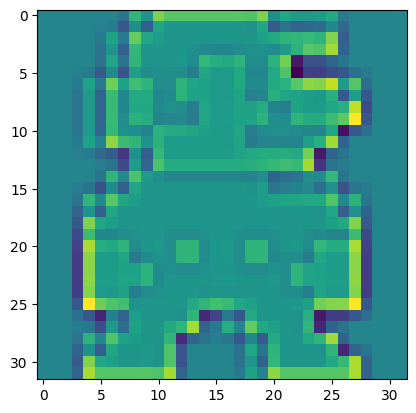

In [ ]:
kernel = torch.tensor([
    [-1., -1., -1.],
    [-1.,  9., -1.],
    [-1., -1., -1.]
])

kernel = kernel.view(1, 1, 3, 3)  # Rearrange into the proper tensor shape

kernel = kernel.repeat(1, 4, 1, 1)  # Apply this filter to all 4 channels simultaneously
conv = torch.conv2d(upscaled_mario.float(), kernel, padding=1)  # Actually doing the convolution

rgb_tensor = conv[0,:3,:,:].permute(1,2,0)  # This changes it into a siple RGB tensor that matplotlib can handle
plt.imshow(rgb_tensor)

The difference is not huge, but you can see the convolution seems to have somewhat increased the resolution by sharpening the diagnonal sections. If we applied lots of much smarter convolutions that learned how to reconstruct the image, hopefully now you see that it should be possible. Hence the magic of deconvolutions!